In [10]:
# ==============================================================================
# БЛОК 1: Инициализация данных для FutureScore PRO
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Загружаем обогащенный датасет
df = pd.read_csv('final_dataset_pro.csv')
print(f"📦 Данные загружены. Размер: {df.shape}")

# 2. Отделяем признаки (X) от цели (y)
X = df.drop('target', axis=1)
y = df['target']

# 3. Разделение на Train и Test (80/20) со стратификацией (сохраняем баланс 85/15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"🛠 Обучающая выборка: {X_train.shape[0]} заявок")
print(f"🧪 Тестовая выборка: {X_test.shape[0]} заявок")

📦 Данные загружены. Размер: (33600, 10)
🛠 Обучающая выборка: 26880 заявок
🧪 Тестовая выборка: 6720 заявок


In [11]:
# ==============================================================================
# БЛОК 2: Обучение предиктивной модели (XGBoost)
# ==============================================================================
print("🧠 Инициализация обучения FutureScore AI...")

# Вычисляем вес для балансировки классов (чтобы ИИ не игнорировал редкие отказы)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Настраиваем параметры модели (легкий тюнинг для стабильности)
model = xgb.XGBClassifier(
    n_estimators=400,        # Чуть больше деревьев для глубокого анализа
    max_depth=5,             # Оптимальная глубина (защита от переобучения)
    learning_rate=0.05,      # Плавное обучение
    scale_pos_weight=ratio,  # Фокус на "проблемных" заявках
    eval_metric='auc',       # Главная метрика хакатона
    random_state=42,
    use_label_encoder=False
)

# Запускаем тренировку
model.fit(X_train, y_train)

# Делаем предсказания на тестовой (невидимой) выборке
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# Выводим метрики для жюри
print("\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ (Test Set) ===")
print(f"🏆 ROC-AUC (Качество ранжирования): {roc_auc_score(y_test, probs):.4f}")
print(f"✅ Accuracy (Общая точность): {accuracy_score(y_test, preds):.4f}\n")

print("Детальный отчет по классами (Classification Report):")
print(classification_report(y_test, preds, target_names=['Отказ/Риск (0)', 'Успех (1)']))

🧠 Инициализация обучения FutureScore AI...

=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ (Test Set) ===
🏆 ROC-AUC (Качество ранжирования): 0.7853
✅ Accuracy (Общая точность): 0.6887

Детальный отчет по классами (Classification Report):
                precision    recall  f1-score   support

Отказ/Риск (0)       0.28      0.73      0.41       995
     Успех (1)       0.94      0.68      0.79      5725

      accuracy                           0.69      6720
     macro avg       0.61      0.71      0.60      6720
  weighted avg       0.84      0.69      0.73      6720



🔍 Анализируем логику модели (SHAP)...


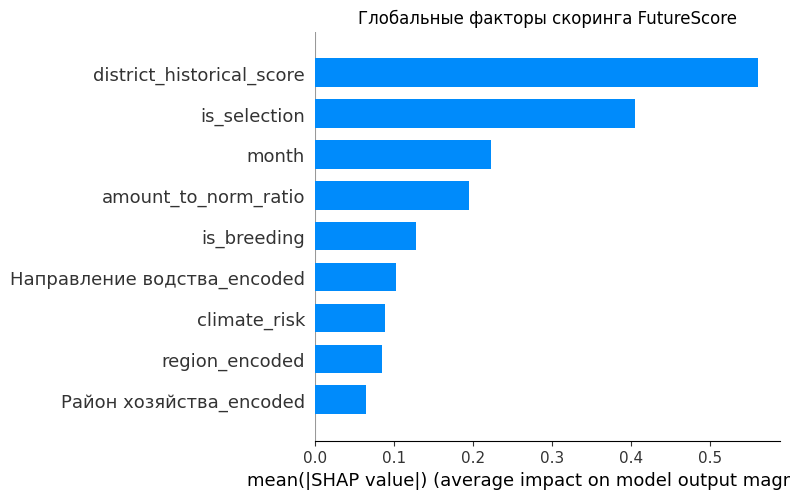


👨‍🌾 РАЗБОР ЗАЯВКИ №42 (Балл: 96.5/100)


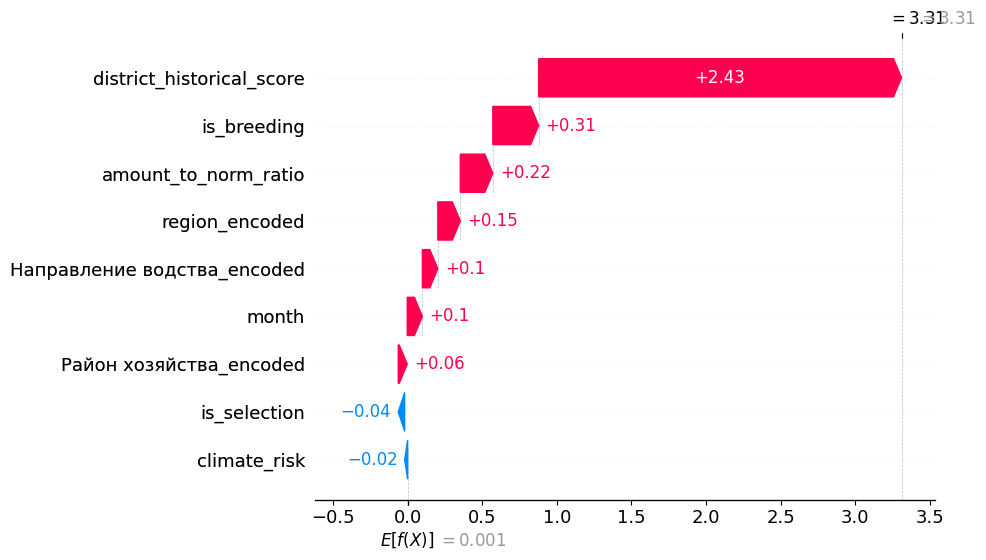

In [13]:
# ==============================================================================
# БЛОК 3: Explainable AI (SHAP) - Прозрачность решений
# ==============================================================================
!pip install shap -q
import shap
import matplotlib.pyplot as plt

print("🔍 Анализируем логику модели (SHAP)...")

# Создаем объяснитель на основе нашего XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1. ГЛОБАЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ
plt.figure(figsize=(10, 6))
plt.title("Глобальные факторы скоринга FutureScore")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# 2. ЛОКАЛЬНАЯ ВАЖНОСТЬ (Разбор конкретного фермера)
idx = 42 # Выбираем случайного фермера для теста
probs = model.predict_proba(X_test)[:, 1]
score = np.round(probs[idx] * 100, 1)

print(f"\n👨‍🌾 РАЗБОР ЗАЯВКИ №{idx} (Балл: {score}/100)")
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=X_test.columns,
    show=True
)

In [16]:
# ==============================================================================
# БЛОК 4: GovTech Advisor 2.0 (Умные рекомендации для комиссии)
# ==============================================================================
def govtech_advisor_pro(farmer_idx, X_test_data, model_xgb):
    farmer_profile = X_test_data.iloc[[farmer_idx]].copy()
    current_score = model_xgb.predict_proba(farmer_profile)[:, 1][0] * 100

    climate = farmer_profile['climate_risk'].iloc[0]

    print(f"👨‍🌾 Анализ заявки №{farmer_idx}")
    print(f"📉 FutureScore: {current_score:.1f}/100")

    # --- СИСТЕМА СВЕТОФОР ---
    if current_score >= 80:
        print("🟢 СТАТУС: Высокий потенциал. Рекомендуется полное одобрение.")
        return
    elif current_score >= 60:
        print("🟡 СТАТУС: Средний риск. Требует внимания комиссии.")
    else:
        print("🔴 СТАТУС: Высокий риск неэффективности.")

    print("\n🔍 АНАЛИЗ ИИ-СОВЕТНИКА:")
    found_solution = False

    # 1. Проверка климатического форс-мажора (НАША УНИКАЛЬНАЯ ФИЧА!)
    if climate >= 0.7:
        print(f"   ⚠️ ВНИМАНИЕ: Хозяйство находится в зоне повышенного климатического риска (индекс {climate:.2f}).")
        print("      Низкий балл может быть обусловлен системными факторами региона (засуха/неурожай), а не плохим управлением.")
        print("      Рекомендация: Индивидуальное рассмотрение. Предложить субсидии на системы орошения.")
        found_solution = True

    # 2. Сценарий: Племенное дело
    if farmer_profile['is_breeding'].iloc[0] == 0:
        sim_1 = farmer_profile.copy()
        sim_1['is_breeding'] = 1
        new_score = model_xgb.predict_proba(sim_1)[:, 1][0] * 100
        delta = new_score - current_score
        if delta > 1.0:
            print(f"   💡 ИДЕЯ: Переход на племенное поголовье поднимет балл до {new_score:.1f} (+{delta:.1f}).")
            found_solution = True

    # 3. Сценарий: Финансовая нагрузка
    current_ratio = farmer_profile['amount_to_norm_ratio'].iloc[0]
    if current_ratio > 0.8:
        sim_2 = farmer_profile.copy()
        sim_2['amount_to_norm_ratio'] = current_ratio * 0.7
        new_score_2 = model_xgb.predict_proba(sim_2)[:, 1][0] * 100
        delta_2 = new_score_2 - current_score
        if delta_2 > 1.0:
            print(f"   💡 ИДЕЯ: Частичное финансирование (снижение запроса на 30%) поднимет балл до {new_score_2:.1f} (+{delta_2:.1f}).")
            found_solution = True

    if not found_solution:
        print("   ❌ Заявка составлена оптимально для текущих условий. Очевидных путей автоматической оптимизации нет.")
        print("      Рекомендация: Отклонить или запросить расширенный бизнес-план.")

# Тестируем на случайных фермерах
print("-" * 60)
govtech_advisor_pro(24, X_test, model)
print("-" * 60)
govtech_advisor_pro(1030, X_test, model)

------------------------------------------------------------
👨‍🌾 Анализ заявки №24
📉 FutureScore: 61.0/100
🟡 СТАТУС: Средний риск. Требует внимания комиссии.

🔍 АНАЛИЗ ИИ-СОВЕТНИКА:
   ❌ Заявка составлена оптимально для текущих условий. Очевидных путей автоматической оптимизации нет.
      Рекомендация: Отклонить или запросить расширенный бизнес-план.
------------------------------------------------------------
👨‍🌾 Анализ заявки №1030
📉 FutureScore: 76.6/100
🟡 СТАТУС: Средний риск. Требует внимания комиссии.

🔍 АНАЛИЗ ИИ-СОВЕТНИКА:
   💡 ИДЕЯ: Частичное финансирование (снижение запроса на 30%) поднимет балл до 81.7 (+5.0).


In [17]:
# ==============================================================================
# БЛОК 5: Экспорт артефактов модели (Для Streamlit Web App)
# ==============================================================================
import pickle

final_artifacts_pro = {
    'xgboost_model': model,
    'explainer': explainer
}

with open('futurescore_model_pro.pkl', 'wb') as f:
    pickle.dump(final_artifacts_pro, f)

print("\n📦 СУПЕР ИИ УПАКОВАН! Файл 'futurescore_model_pro.pkl' сохранен.")


📦 СУПЕР ИИ УПАКОВАН! Файл 'futurescore_model_pro.pkl' сохранен.
